In [1]:
import pandas as pd

In [2]:
import sys
sys.path.append("../../training_data/")

In [3]:
from utils.utils import *

In [4]:
extra_path = "../../training_data/7.Extra_set"
extra_original_cifs_path = f"{extra_path}/origcifs"

extra_structures_path = "cifs"
os.makedirs(extra_structures_path, exist_ok=True)

extra_pockets_path = "pockets"
os.makedirs(extra_pockets_path, exist_ok=True)

extra_features_path = "."
os.makedirs("features", exist_ok=True)

Cif.path = extra_structures_path
Cif.original_cifs_path = extra_original_cifs_path

# Data

In [5]:
news_sitesf = f"{extra_path}/news_sites.pkl"

with open(news_sitesf, "rb") as f:
    news_sites = {
        k: v
        for k, v in pd.read_pickle(f).items()
        if k not in ('6l57', '6t65', '6zod') # they were annotated in the new dict because they are in the same primary reference as hits but were alread in the database
    }

news_sites

{'22mj': [{'mod':      label_comp_id label_asym_id label_entity_id label_seq_id  \
   2394         A1MDP             H               4            .   
   
        pdbx_PDB_ins_code auth_seq_id auth_comp_id auth_asym_id  \
   2394                 ?         407        A1MDP            A   
   
        pdbx_PDB_model_num pdbx_label_index  
   2394                  1              407  ,
   'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            THR             A               1          118                 ?   
   1            PRO             A               1          119                 ?   
   2            THR             A               1          120                 ?   
   3            LYS             A               1          129                 ?   
   4            GLY             A               1          130                 ?   
   5            GLY             A               1          131                 ?   
   6            VA

In [82]:
news_seqsf = f"{extra_path}/news_seqs.pkl"

with open(news_seqsf, "rb") as f:
    news_seqs = pd.read_pickle(f)

news_seqs

{('22mj',
  '1',
  'A'): 'MSSRKLSGPKGRRLSIHVVTWNVASAAPPLDLSDLLQLNNRNLNLDIYVIGLQELNSGIISLLSDAAFNDSWSSFLMDVLSPLSFIKVSHVRMQGILLLVFAKYQHLPYIQILSTKSTPTGLFGYWGNKGGVNICLKLYGYYVSIINCHLPPHISNNYQRLEHFDRILEMQNCEGRDIPNILDHDLIIWFGDMNFRIEDFGLHFVRESIKNRCYGGLWEKDQLSIAKKHDPLLREFQEGRLLFPPTYKFDRNSNDYDTSEKKRKPAWTDRILWRLKRQPAKANPSGFLLTQKDYSSHMTYGISDHKPVSGTFDLELKPLVSA',
 ('6l57',
  '1',
  'A'): 'MGSTGGVQTVTLIPGDGIGPEISAAVMKIFDAAKAPIQWEERNVTAIQGPGGKWMIPSEAKESMDKNKMGLKGPLKTPIAAGHPSMNLLLRKTFDLYANVRPCVSIEGYKTPYTDVNIVTIRENTEGEYSGIEHVIVDGVVQSIKLITEGASKRIAEFAFEYARNNHRSNVTAVHKANIMRMSDGLFLQKCREVAESCKDIKFNEMYLDTVCLNMVQDPSQFDVLVMPNLYGDILSDLCAGLIGGLGVTPSGNIGANGVAIFESVHGTAPDIAGKDMANPTALLLSAVMMLRHMGLFDHAARIEAACFATIKDGKSLTKDLGGNAKCSDFTEEICRRVKDLD',
 ('6l57',
  '2',
  'B'): 'MGSFSEQTIPPSAKYGGRHTVTMIPGDGIGPELMLHVKSVFRHACVPVDFEEVHVSSNADEEDIRNAIMAIRRNRVALKGNIETNHNLPPSHKSRNNILRTSLDLYANVIHCKSLPGVVTRHKDIDILIVRENTEGEYSSLEHESVAGVVESLKIITKAKSLRIAEYAFKLAQESGRKKVTAVHKANIMKLGDGLFLQCCREVAARYPQITFENMIVDNTTMQLVSRPQQFDVMVMPNLYGNIVNNVCAGLV

# -mers annotations

In [7]:
mmseqs = pd.read_csv(f"{extra_path}/mmseqs2/second_cluster.tsv", sep="\t", header=None)
mmseqs

,0,1
0,22mj_1_A,22mj_1_A
1,7v6g_1_A,7v6g_1_A
2,7v6g_1_A,7v6g_1_B
3,6r8g_1_A,6r8g_1_A
4,6r8g_1_A,6r8g_1_B
...,...,...
3677,8fe1_2_E,8fe1_1_B
3678,8fe1_2_E,8fe1_1_C
3679,4op0_1_A,4op0_1_A
3680,2be9_2_B,2be9_2_B


In [8]:
# Map each cluster rep to a unique cluster ID
mmseq_ids = {cid: i for i, cid in enumerate(mmseqs[0].unique())}
mmseq_ids

{'22mj_1_A': 0,
 '7v6g_1_A': 1,
 '6r8g_1_A': 2,
 '6s3a_1_A': 3,
 '6vvq_1_C': 4,
 '6on4_1_A': 5,
 '6ymh_1_B': 6,
 '6z1m_1_A': 7,
 '6z74_1_A': 8,
 '7ac8_1_A': 9,
 '7agj_1_A': 10,
 '7e1n_1_A': 11,
 '7e40_2_B': 12,
 '7egk_2_B': 13,
 '7gqu_1_A': 14,
 '7oy0_1_A': 15,
 '7p2v_1_A': 16,
 '7pol_1_A': 17,
 '7pt0_1_A': 18,
 '7qpn_1_A': 19,
 '7ry1_1_A': 20,
 '7snh_1_A': 21,
 '7sql_1_A': 22,
 '7u3a_1_A': 23,
 '7u4k_1_A': 24,
 '7v39_1_B': 25,
 '7yg5_1_A': 26,
 '7zpe_1_A': 27,
 '8aq6_1_G': 28,
 '8cgw_1_A': 29,
 '8crc_1_A': 30,
 '8d4i_1_A': 31,
 '8dsc_1_A': 32,
 '8e1u_1_A': 33,
 '8e23_1_A': 34,
 '8fdb_1_A': 35,
 '8f4s_1_A': 36,
 '8fpi_1_A': 37,
 '8hub_1_B': 38,
 '8hx9_1_A': 39,
 '8jb3_1_A': 40,
 '8jp0_1_A': 41,
 '8ooo_1_A': 42,
 '8p23_1_A': 43,
 '8qa6_1_A': 44,
 '8qni_1_A': 45,
 '8qud_1_A': 46,
 '9hg1_1_A': 47,
 '8sev_1_A': 48,
 '8thm_1_A': 49,
 '8uk6_1_A': 50,
 '8v81_1_A': 51,
 '8v90_1_A': 52,
 '8xlr_1_A': 53,
 '9b96_1_A': 54,
 '9d2r_1_A': 55,
 '9dnm_3_C': 56,
 '9du7_1_A': 57,
 '9ebs_3_C': 58,
 '9ema_

In [9]:
# Define each PDB (not each sequence) by the cluster IDs to which the sequences of its chains belong to (# of chains per pdb per cluster) (only clust. reps of news)
mmer_clust_ids = {}

for i, row in tqdm(
    (
        mmseqs
        .loc[lambda x: [i.split("_")[0] in news_sites for i in x[1]]]
        .iterrows()
    ), 
    smoothing=0
):
    p, entity_id, asym_id = row[1].split("_")
    cid = mmseq_ids[row[0]]
    if p not in mmer_clust_ids:
        mmer_clust_ids[p] = {}
    mmer_clust_ids[p][cid] = mmer_clust_ids[p].get(cid, 0) + 1

dict(sorted(mmer_clust_ids.items(), key=lambda x: x[0]))

0it [00:00, ?it/s]

{'22mj': {0: 1},
 '6on4': {5: 1},
 '6r8g': {2: 4},
 '6s3a': {3: 1},
 '6t3w': {3: 1},
 '6vvq': {4: 1},
 '6ymh': {6: 1},
 '6z1m': {7: 1},
 '6z74': {8: 1},
 '7ac8': {9: 1},
 '7agj': {10: 2},
 '7e1n': {11: 2},
 '7e40': {12: 1},
 '7egk': {13: 3},
 '7gqu': {14: 1},
 '7k1c': {52: 2},
 '7oy0': {15: 1},
 '7p2v': {16: 1},
 '7pol': {17: 2},
 '7pt0': {18: 1},
 '7qpn': {19: 1},
 '7ry1': {20: 1},
 '7snh': {21: 4},
 '7sql': {22: 4},
 '7u3a': {23: 2},
 '7u4k': {24: 1},
 '7v39': {25: 1},
 '7v6g': {1: 2},
 '7yg5': {26: 1},
 '7zpe': {27: 1},
 '8aq6': {28: 2},
 '8cgw': {29: 1},
 '8crc': {30: 1},
 '8d4i': {31: 2},
 '8dsc': {32: 2},
 '8e1u': {33: 2},
 '8e23': {34: 1},
 '8f4s': {36: 1},
 '8fdb': {35: 2},
 '8fpi': {37: 1},
 '8hub': {38: 3},
 '8hx9': {39: 1},
 '8jb3': {40: 1},
 '8jp0': {41: 1},
 '8ooo': {42: 12},
 '8p23': {43: 2},
 '8qa6': {44: 2},
 '8qni': {45: 1},
 '8qtk': {45: 1},
 '8qud': {46: 4},
 '8sev': {48: 4},
 '8thm': {49: 6},
 '8tm7': {32: 2},
 '8uk6': {50: 1},
 '8v81': {51: 1},
 '8v90': {52: 2},
 '

New PDBs that are heteromers (only two heterodimers) have chains that are the only cluster member for their respective cluster.

<br>

In [10]:
# Only representatives
mmer_clust_ids_reps = {
    k: v
    for k,v in mmer_clust_ids.items()
    if k in mmseqs[0].apply(lambda x: x.split("_", 1)[0]).unique()
}

len(mmer_clust_ids_reps), mmer_clust_ids_reps

(74,
 {'22mj': {0: 1},
  '7v6g': {1: 2},
  '6r8g': {2: 4},
  '6s3a': {3: 1},
  '6vvq': {4: 1},
  '6on4': {5: 1},
  '6ymh': {6: 1},
  '6z1m': {7: 1},
  '6z74': {8: 1},
  '7ac8': {9: 1},
  '7agj': {10: 2},
  '7e1n': {11: 2},
  '7e40': {12: 1},
  '7egk': {13: 3},
  '7gqu': {14: 1},
  '7oy0': {15: 1},
  '7p2v': {16: 1},
  '7pol': {17: 2},
  '7pt0': {18: 1},
  '7qpn': {19: 1},
  '7ry1': {20: 1},
  '7snh': {21: 4},
  '7sql': {22: 4},
  '7u3a': {23: 2},
  '7u4k': {24: 1},
  '7v39': {25: 1},
  '7yg5': {26: 1},
  '7zpe': {27: 1},
  '8aq6': {28: 2},
  '8cgw': {29: 1},
  '8crc': {30: 1},
  '8d4i': {31: 2},
  '8dsc': {32: 2},
  '8e1u': {33: 2},
  '8e23': {34: 1},
  '8fdb': {35: 2},
  '8f4s': {36: 1},
  '8fpi': {37: 1},
  '8hub': {38: 3},
  '8hx9': {39: 1},
  '8jb3': {40: 1},
  '8jp0': {41: 1},
  '8ooo': {42: 12},
  '8p23': {43: 2},
  '8qa6': {44: 2},
  '8qni': {45: 1},
  '8qud': {46: 4},
  '9hg1': {47: 8},
  '8sev': {48: 4},
  '8thm': {49: 6},
  '8uk6': {50: 1},
  '8v81': {51: 1},
  '8v90': {52: 2

In [11]:
dict(sorted(
    (
        (k, v)
        for k,v in mmer_clust_ids_reps.items()
        if len(v) == 2
    ), 
    key=lambda x: x[0]
))

{'9ohl': {68: 1, 69: 1}, '9xro': {71: 1, 72: 1}}

In [12]:
# decision: heteromers will only contain chains in contact with modulators
# for homomers, all chains in assembly/manual annotation will be included

# 9ohl is fine
# 9xro is a trimer, but the dimer is fine

good_oligomers = {
    "9ohl": None,
    "9xro": None
}

In [13]:
homomers = dict(sorted(
    (
        (k, v)
        for k,v in mmer_clust_ids_reps.items()
        if len(v) == 1 and tuple(v.values())[0] > 1
    ), 
    key=lambda x: tuple(x[1].values())[0],
    reverse=True
))

len(homomers), homomers

(32,
 {'8ooo': {42: 12},
  '9hg1': {47: 8},
  '9z2f': {74: 8},
  '8thm': {49: 6},
  '9ema': {59: 6},
  '6r8g': {2: 4},
  '7snh': {21: 4},
  '7sql': {22: 4},
  '8qud': {46: 4},
  '8sev': {48: 4},
  '9it0': {62: 4},
  '9zq0': {75: 4},
  '7egk': {13: 3},
  '8hub': {38: 3},
  '7v6g': {1: 2},
  '7agj': {10: 2},
  '7e1n': {11: 2},
  '7pol': {17: 2},
  '7u3a': {23: 2},
  '8aq6': {28: 2},
  '8d4i': {31: 2},
  '8dsc': {32: 2},
  '8e1u': {33: 2},
  '8fdb': {35: 2},
  '8p23': {43: 2},
  '8qa6': {44: 2},
  '8v90': {52: 2},
  '8xlr': {53: 2},
  '9du7': {57: 2},
  '9hgm': {61: 2},
  '9l65': {63: 2},
  '9yic': {73: 2}})

In [14]:
# decision: only tetramers and down

# 7sql has bad ligand quality
# 9zq0 is from a preprint
# 7egk is an hexamer (heterodimer of homotimers) but mods only contact 3 chains; it's fine
# 8hub is a tetramer and has bad ligand quality
# 8aq6 bad ligand quality
# 8e1u has ok-bad ligand quality
# 8v90 has bad ligand quality
# 9yic has bad ligand quality

good_oligomers.update({
    k: None
    for k, v in homomers.items()
    if (
        k not in ['7sql', '9zq0', '8hub', '8aq6', '8e1u', '8v90', '9yic']
        and tuple(v.values())[0] <= 4 # tetramers or less
    )
})

good_oligomers

{'9ohl': None,
 '9xro': None,
 '6r8g': None,
 '7snh': None,
 '8qud': None,
 '8sev': None,
 '9it0': None,
 '7egk': None,
 '7v6g': None,
 '7agj': None,
 '7e1n': None,
 '7pol': None,
 '7u3a': None,
 '8d4i': None,
 '8dsc': None,
 '8fdb': None,
 '8p23': None,
 '8qa6': None,
 '8xlr': None,
 '9du7': None,
 '9hgm': None,
 '9l65': None}

In [15]:
monomers = dict(sorted(
    (
        (k, v)
        for k,v in mmer_clust_ids_reps.items()
        if len(v) == 1 and tuple(v.values())[0] == 1
    ), 
    key=lambda x: x[0]
))

print(len(monomers), monomers)

40 {'22mj': {0: 1}, '6on4': {5: 1}, '6s3a': {3: 1}, '6vvq': {4: 1}, '6ymh': {6: 1}, '6z1m': {7: 1}, '6z74': {8: 1}, '7ac8': {9: 1}, '7e40': {12: 1}, '7gqu': {14: 1}, '7oy0': {15: 1}, '7p2v': {16: 1}, '7pt0': {18: 1}, '7qpn': {19: 1}, '7ry1': {20: 1}, '7u4k': {24: 1}, '7v39': {25: 1}, '7yg5': {26: 1}, '7zpe': {27: 1}, '8cgw': {29: 1}, '8crc': {30: 1}, '8e23': {34: 1}, '8f4s': {36: 1}, '8fpi': {37: 1}, '8hx9': {39: 1}, '8jb3': {40: 1}, '8jp0': {41: 1}, '8qni': {45: 1}, '8uk6': {50: 1}, '8v81': {51: 1}, '9b96': {54: 1}, '9d2r': {55: 1}, '9dnm': {56: 1}, '9ebs': {58: 1}, '9fsj': {60: 1}, '9lhf': {64: 1}, '9mfs': {65: 1}, '9ntc': {66: 1}, '9oga': {67: 1}, '9oul': {70: 1}}


In [16]:
diverse_newsf = f"{extra_path}/diverse_news.pkl"

with open(diverse_newsf, "rb") as f:
    diverse_news = pickle.load(f)

print(len(diverse_news), diverse_news)

21 {'22mj': {'label_asym_id': ['H']}, '6s3a': {'label_asym_id': ['B']}, '6vvq': {'label_asym_id': ['E']}, '6z1m': {'label_asym_id': ['D']}, '7gqu': {'label_asym_id': ['D']}, '7p2v': {'label_asym_id': ['F']}, '7qpn': {'label_asym_id': ['C']}, '7yg5': {'label_asym_id': ['V']}, '7zpe': {'label_asym_id': ['G']}, '8crc': {'label_asym_id': ['C']}, '8f4s': {'label_asym_id': ['D']}, '8fpi': {'label_asym_id': ['F']}, '8jp0': {'label_asym_id': ['B']}, '8qni': {'label_asym_id': ['B']}, '8uk6': {'label_asym_id': ['C']}, '8v81': {'label_asym_id': ['L']}, '9ebs': {'label_asym_id': ['F']}, '9fsj': {'label_asym_id': ['B']}, '9mfs': {'label_asym_id': ['B']}, '9ntc': {'label_asym_id': ['B']}, '9oul': {'label_asym_id': ['D']}}


In [17]:
monomers_left = {
    k: v 
    for k, v in monomers.items() 
    if k not in (
        list(diverse_news) 
        + [
            '7e40', '7u4k', '7v39', '8cgw', # bad ligand resolution from original nb
            '9dnm', '9oga' # preprints from original nb
        ] 
    )
}

len(monomers_left), monomers_left

(13,
 {'6on4': {5: 1},
  '6ymh': {6: 1},
  '6z74': {8: 1},
  '7ac8': {9: 1},
  '7oy0': {15: 1},
  '7pt0': {18: 1},
  '7ry1': {20: 1},
  '8e23': {34: 1},
  '8hx9': {39: 1},
  '8jb3': {40: 1},
  '9b96': {54: 1},
  '9d2r': {55: 1},
  '9lhf': {64: 1}})

From original notebook: **Differences between the annotated and the extracted oligomeric state:**
- 6on4 is a functional dimer
- 6ymh is a functional dimer
- 6z74 is a functional tetramer but the allosteric site is only on 1 chain
- 7ac8 dimer
- 7oy0 is a functional dimer
- 7pt0 is a functional dimer but the allosteric site is only on 1 chain
- 7ry1 is a hexamer and the model is a trimer which could reconstruct the hexamer in the assembly, but they haven't done it
- 8e23 is probably a dimer or tetramer but neither the model or the assembly are
- 8hx9 dimer
- 8jb3 is a functional tetramer
- 9b96 is a functional dimer, but model is monomeric and thus assembly is repetition-based
- 9d2r is a functional dimer, but model is monomeric and thus assembly is repetition-based
- 9lhf is a dimer but there is only 1 molecule interacting with 1 chain

<br>

In [18]:
good_oligomers.update({
    '6on4': ["A", "B"],
    # '6ymh': ["A", "B"], # bad ligand quality
    '6z74': ["A", "B", "C", "D"],
    '7ac8': ["A", "B"],
    # '7oy0': {15: 1}, # repetition-based assembly, dimer not available model
    '7pt0': ["A", "B"],
    # '7ry1': # is a hexamer
    # '8e23': {37: 1}, # bad ligand quality
    # '8hx9': {42: 1}, # bad ligand quality
    # '8jb3': {43: 1}, # it is a functional tetramer but isn't in model nor assembly
    # '9b96': {57: 1}, # repetition-based assembly, dimer not available model
    # '9d2r': {58: 1}, # repetition-based assembly, dimer not available model
    '9lhf': ["A", "B"]
})

In [19]:
len(good_oligomers), good_oligomers

(27,
 {'9ohl': None,
  '9xro': None,
  '6r8g': None,
  '7snh': None,
  '8qud': None,
  '8sev': None,
  '9it0': None,
  '7egk': None,
  '7v6g': None,
  '7agj': None,
  '7e1n': None,
  '7pol': None,
  '7u3a': None,
  '8d4i': None,
  '8dsc': None,
  '8fdb': None,
  '8p23': None,
  '8qa6': None,
  '8xlr': None,
  '9du7': None,
  '9hgm': None,
  '9l65': None,
  '6on4': ['A', 'B'],
  '6z74': ['A', 'B', 'C', 'D'],
  '7ac8': ['A', 'B'],
  '7pt0': ['A', 'B'],
  '9lhf': ['A', 'B']})

## .cif reprocessing

In [20]:
from utils.new_pdbs import Pdb
from utils.structure_fixing import get_fixed_structure

In [21]:
errors = []

for new, chains in tqdm(tuple(good_oligomers.items()), smoothing=0):
    new = new.lower()
    newf = f"{extra_structures_path}/{new}.cif"
    
    if not os.path.isfile(newf):
        if chains is None:
            os.system(f"cp {extra_path}/cifs/{new}.cif {newf}")
            continue
        
        else:
            pdb = Pdb(new)
            origciff = f"{extra_original_cifs_path}/{new}_updated.cif.gz"
            pdb.filename = origciff
            pdb.cif.filename = origciff
            p = pdb
            
            try:
                get_fixed_structure(pdb, pdb, chains, extra_structures_path, save=True)
            except Exception as e:
                print(pdb, e)
                errors[pdb] = e

  0%|          | 0/27 [00:00<?, ?it/s]

# Pockets

In [22]:
from utils.pocket_utils import Pocket, get_pocket_view, get_pockets_info, get_mean_pocket_features

In [23]:
view_pocket = lambda pdb, pocket: get_pocket_view(
    pdb = pdb, 
    cif = Cif(pdb),
    pocket = pocket,
    pockets_path = extra_pockets_path,
    sites = news_sites[pdb]
)

## "Old" FPocket

In [24]:
def hunt_pockets(pdb):    
    path = f"{extra_pockets_path}/{pdb}"
    if os.path.isdir(path):
        return
    else:
        print(pdb)
        os.makedirs(path, exist_ok=True)
        os.system(f"cp {extra_structures_path}/{pdb}.cif {path}/")
        os.system(f"fpocket -m 3 -M 6 -i 35 --file {path}/{pdb}.cif") # utils/external/fpocket/bin/fpocket

In [25]:
for pdb in tqdm(good_oligomers, smoothing=0):
    hunt_pockets(pdb)

  0%|          | 0/27 [00:00<?, ?it/s]

### Process

In [26]:
pockets = pd.DataFrame((
    pocket
    for pdb in tqdm(good_oligomers, smoothing=0)
    for pocket in get_pockets_info(
        Cif(pdb), 
        sites = news_sites[pdb],
        pockets_path = extra_pockets_path
    )
))

pockets

  0%|          | 0/27 [00:00<?, ?it/s]

,pdb,pocket,nres,site_in_pocket,pocket_in_site
0,9ohl,pocket16,8,0.000000,0.000000
1,9ohl,pocket11,19,0.000000,0.000000
2,9ohl,pocket15,26,0.863636,0.730769
3,9ohl,pocket7,12,0.000000,0.000000
4,9ohl,pocket13,7,0.000000,0.000000
...,...,...,...,...,...
1235,9lhf,pocket5,20,0.000000,0.000000
1236,9lhf,pocket8,20,0.000000,0.000000
1237,9lhf,pocket3,20,0.000000,0.000000
1238,9lhf,pocket12,14,0.000000,0.000000


In [27]:
len(good_oligomers), len(pockets.pdb.unique())

(27, 27)

### Pocket size

In [28]:
pockets.sort_values("nres", ascending=False)

,pdb,pocket,nres,site_in_pocket,pocket_in_site
962,8qa6,pocket1,384,0.593220,0.091146
1215,7pt0,pocket1,131,0.909091,0.152672
892,8p23,pocket1,131,0.000000,0.000000
1171,6z74,pocket1,119,0.360000,0.075630
360,9it0,pocket210,99,0.000000,0.000000
...,...,...,...,...,...
667,7agj,pocket71,6,0.000000,0.000000
1151,6on4,pocket10,6,0.000000,0.000000
723,7u3a,pocket18,6,0.000000,0.000000
670,7agj,pocket38,5,0.000000,0.000000


<Axes: >

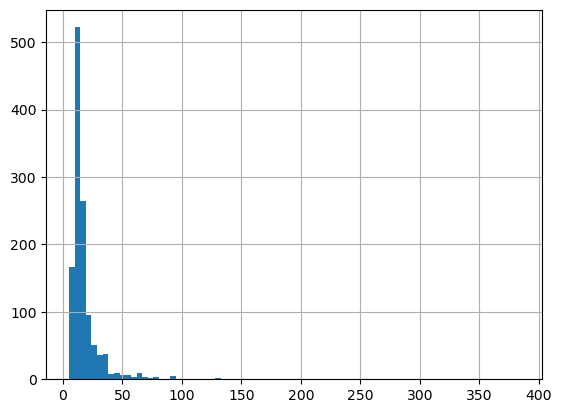

In [29]:
pockets.nres.hist(bins=80)

### Labelling

In [30]:
pockets["label"] = 0
pockets.loc[
    pockets.loc[
        lambda x: round(x["site_in_pocket"], 2) >= 0.65
    ].index, 
    "label"
] = 1
# pockets["label"] = pockets["label"].fillna(0).astype(int)

pockets.sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
165,8qud,pocket16,63,0.950000,0.301587,1
176,8qud,pocket64,66,0.950000,0.287879,1
192,8qud,pocket1,64,0.950000,0.296875,1
198,8qud,pocket2,65,0.950000,0.292308,1
604,7v6g,pocket6,24,0.944444,0.708333,1
28,9xro,pocket1,81,0.931034,0.333333,1
895,8p23,pocket58,58,0.925926,0.431034,1
1215,7pt0,pocket1,131,0.909091,0.152672,1
1200,7ac8,pocket1,49,0.871795,0.693878,1
1069,9hgm,pocket28,93,0.869565,0.430108,1


In [31]:
for pdb in good_oligomers:
    print(pdb, len(news_sites[pdb]), pockets.query(f"pdb == '{pdb}'").label.sum())

9ohl 1 1
9xro 1 1
6r8g 4 4
7snh 4 0
8qud 4 4
8sev 4 0
9it0 4 0
7egk 3 3
7v6g 2 2
7agj 2 0
7e1n 2 2
7pol 2 2
7u3a 2 0
8d4i 1 0
8dsc 2 2
8fdb 1 1
8p23 2 1
8qa6 2 0
8xlr 2 2
9du7 2 0
9hgm 2 2
9l65 2 2
6on4 1 0
6z74 1 1
7ac8 1 1
7pt0 1 1
9lhf 1 0


#### Inspection

In [32]:
import molviewspec as mvs
import json

In [33]:
def view_pockets(pdb, site_in_pocket=None, pocket_in_site=None):# pdb = "9ouk"
    builder = mvs.create_builder()
    structure = (
        builder.download(url=f"{pdb}.cif")
        .parse(format="mmcif")
        .model_structure()
    )

    cif = Cif(f"{pdb}_out", f"pockets/{pdb}/{pdb}_out/{pdb}_out.cif")
    cif._name = f"{pdb}_out"

    origstructure = (
        builder.download(url=f"{pdb}_orig.cif")
        .parse(format="mmcif")
        .model_structure()
    )
    cif.origcif._name = pdb.upper()
    cif.origcif.filename = f"{extra_original_cifs_path}/{pdb}_updated.cif.gz"

    assets = {
        f'{pdb}.cif': cif.cif.text.encode(),
        f'{pdb}_orig.cif': cif.origcif.text.encode(),
    }
    
    protein = structure.component().representation()
    pkts = structure.component(selector=[mvs.ComponentExpression(label_comp_id = "STP")]).representation(type="ball_and_stick").color(color="darkgrey").opacity(opacity=0.5)

    mask = pockets.query(f"pdb == '{pdb}'")
    mask = mask[
        ( (mask["site_in_pocket"].round(2) >= site_in_pocket) if site_in_pocket is not None else pd.Series(False, index=mask.index) )
        | ( (mask["pocket_in_site"].round(2) >= pocket_in_site) if pocket_in_site is not None else pd.Series(False, index=mask.index) )
    ]
    if len(mask):
        annos = f'annos_pockets.json'
        assets[annos] = json.dumps(
            [
                {
                    'label_comp_id': "STP", 'auth_seq_id': int(r["pocket"].replace("pocket", "")), 
                    'color': 'green' # 'pdbx_PDB_ins_code': r["pdbx_PDB_ins_code"],
                }
                for i, r in mask.iterrows()
            ]
        ).encode()
        pkts.color_from_uri(uri=annos, format='json', schema='all_atomic')



    
    for i, s in enumerate(news_sites[pdb]):
        origstructure.component(
            selector=[mvs.ComponentExpression(label_asym_id = m) for m in s["mod"]["label_asym_id"].unique()]
        ).representation(type="ball_and_stick").color(color="blue").opacity(opacity=0.5)
        
        annos = f'annos_site_{i}.json'
        assets[annos] = json.dumps(
            [
                {
                    'auth_asym_id': r["auth_asym_id"], 'auth_seq_id': int(r["auth_seq_id"]), 
                    'color': 'red' # 'pdbx_PDB_ins_code': r["pdbx_PDB_ins_code"],
                }
                for j, r in s["site"].iterrows()
            ]
        ).encode()
        protein.color_from_uri(uri=annos, format='json', schema='all_atomic')
    
    return mvs.MVSX(
        data=builder.get_state(),
        assets=assets
    )#.molstar_notebook(width= 1200, height= 700)

##### 7snh

In [34]:
pdb = '7snh'

In [35]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
91,7snh,pocket77,20,0.566667,0.850000,0
117,7snh,pocket69,16,0.533333,1.000000,0
118,7snh,pocket58,16,0.533333,1.000000,0
162,7snh,pocket63,16,0.533333,1.000000,0
112,7snh,pocket59,7,0.233333,1.000000,0
126,7snh,pocket67,7,0.233333,1.000000,0
134,7snh,pocket66,7,0.233333,1.000000,0
140,7snh,pocket57,7,0.233333,1.000000,0
92,7snh,pocket74,13,0.200000,0.461538,0
97,7snh,pocket75,13,0.200000,0.461538,0


The pockets would be labelled with 0.5-0.53; using pocket_in_site 0.85-1 would label 8 pockets. Indeed, the allosteric pockets are split in multiple smaller pockets.

<br>

##### 8sev

In [36]:
pdb = "8sev"

In [37]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
272,8sev,pocket13,26,0.555556,0.384615,0
298,8sev,pocket4,26,0.555556,0.384615,0
308,8sev,pocket9,26,0.555556,0.384615,0
356,8sev,pocket6,26,0.555556,0.384615,0
257,8sev,pocket72,16,0.222222,0.250000,0
315,8sev,pocket66,16,0.222222,0.250000,0
319,8sev,pocket114,37,0.222222,0.108108,0
333,8sev,pocket116,37,0.222222,0.108108,0
341,8sev,pocket115,37,0.222222,0.108108,0
344,8sev,pocket113,37,0.222222,0.108108,0


The pockets would be labelled with 0.55, but they are pockets that extend to a much further place than the allosteric site.

<br>

##### 9it0

In [38]:
pdb = "9it0"

In [39]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
364,9it0,pocket194,17,0.395349,1.000000,0
552,9it0,pocket201,15,0.365854,1.000000,0
495,9it0,pocket197,14,0.341463,1.000000,0
396,9it0,pocket206,14,0.333333,1.000000,0
384,9it0,pocket200,15,0.326087,1.000000,0
414,9it0,pocket191,14,0.325581,1.000000,0
393,9it0,pocket72,34,0.309524,0.382353,0
564,9it0,pocket181,14,0.304348,1.000000,0
465,9it0,pocket81,16,0.260870,0.750000,0
432,9it0,pocket102,16,0.255814,0.687500,0


Labelling the pockets would require a very low site_in_pocket value, but pocket_in_site=1 labels two pockets per site, which works great.

<br>

##### 7agj

In [40]:
pdb = "7agj"

In [41]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
613,7agj,pocket49,29,0.454545,0.517241,0
657,7agj,pocket57,13,0.433333,1.000000,0
629,7agj,pocket59,10,0.333333,1.000000,0
677,7agj,pocket33,11,0.333333,1.000000,0
608,7agj,pocket77,12,0.300000,0.750000,0
672,7agj,pocket62,12,0.272727,0.750000,0
607,7agj,pocket76,20,0.233333,0.350000,0
623,7agj,pocket22,14,0.166667,0.357143,0
674,7agj,pocket19,37,0.100000,0.081081,0
666,7agj,pocket50,18,0.066667,0.111111,0


The pockets would be labelled with 0.43-0.45, but also with pocket_in_site 0.75 (and 1 would also work), although pocket49 which also partly overlaps the allosteric pocket would be missing.

<br>

##### 7u3a

In [42]:
pdb = "7u3a"

In [43]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
738,7u3a,pocket1,70,0.538462,0.200000,0
761,7u3a,pocket12,15,0.464286,0.866667,0
759,7u3a,pocket3,56,0.321429,0.160714,0
733,7u3a,pocket31,16,0.269231,0.437500,0
746,7u3a,pocket29,14,0.192308,0.357143,0
743,7u3a,pocket32,13,0.178571,0.384615,0
744,7u3a,pocket20,10,0.142857,0.400000,0
765,7u3a,pocket52,16,0.076923,0.125000,0
731,7u3a,pocket22,10,0.038462,0.100000,0
736,7u3a,pocket14,24,0.038462,0.041667,0


pocket_in_site=0.85, site_in_pocket=0.5 would label the correct pockets, although pocket1 is very big and extends much more than the allosteric site.

<br>

##### 8d4i

In [44]:
pdb = "8d4i"

In [45]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
795,8d4i,pocket12,12,0.357143,0.416667,0
784,8d4i,pocket1,80,0.285714,0.050000,0
787,8d4i,pocket4,15,0.285714,0.266667,0
791,8d4i,pocket5,14,0.285714,0.285714,0
773,8d4i,pocket16,12,0.000000,0.000000,0
774,8d4i,pocket18,22,0.000000,0.000000,0
775,8d4i,pocket11,20,0.000000,0.000000,0
776,8d4i,pocket25,12,0.000000,0.000000,0
777,8d4i,pocket15,19,0.000000,0.000000,0
778,8d4i,pocket7,15,0.000000,0.000000,0


pocket12 partly overlaps the allosteric site but would have a very low threshold value.

<br>

##### 8p23

In [46]:
pdb = "8p23"

In [47]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
895,8p23,pocket58,58,0.925926,0.431034,1
902,8p23,pocket81,40,0.620690,0.450000,0
861,8p23,pocket90,23,0.448276,0.565217,0
932,8p23,pocket87,18,0.241379,0.388889,0
898,8p23,pocket82,18,0.103448,0.166667,0
870,8p23,pocket49,12,0.074074,0.166667,0
872,8p23,pocket72,8,0.068966,0.250000,0
873,8p23,pocket83,14,0.037037,0.071429,0
909,8p23,pocket88,14,0.037037,0.071429,0
862,8p23,pocket16,13,0.000000,0.000000,0


site_in_pocket=0.62 would label the correct pocket that was missing, although that one is split in 3 compared to the one that was already labelled.

<br>

##### 8qa6

In [48]:
pdb = "8qa6"

In [49]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
962,8qa6,pocket1,384,0.593220,0.091146,0
970,8qa6,pocket8,21,0.322034,0.904762,0
976,8qa6,pocket6,21,0.316667,0.904762,0
973,8qa6,pocket12,7,0.033898,0.285714,0
974,8qa6,pocket19,7,0.033333,0.285714,0
951,8qa6,pocket16,34,0.000000,0.000000,0
952,8qa6,pocket18,13,0.000000,0.000000,0
953,8qa6,pocket11,11,0.000000,0.000000,0
954,8qa6,pocket25,12,0.000000,0.000000,0
955,8qa6,pocket15,18,0.000000,0.000000,0


pocket_in_site=0.9 labels two correct pockets, but pocket 1 with site_in_pocket 0.593 is catastrophically the biggest pocket in this batch of structures, covering most of the interior of the protein.

<br>

##### 9du7

In [50]:
pdb = "9du7"

In [51]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1061,9du7,pocket4,17,0.6250,0.588235,0
1066,9du7,pocket3,15,0.6250,0.666667,0
1057,9du7,pocket11,14,0.2500,0.285714,0
1067,9du7,pocket6,8,0.1875,0.375000,0
1058,9du7,pocket7,9,0.0000,0.000000,0
1059,9du7,pocket1,32,0.0000,0.000000,0
1060,9du7,pocket2,20,0.0000,0.000000,0
1062,9du7,pocket9,19,0.0000,0.000000,0
1063,9du7,pocket10,8,0.0000,0.000000,0
1064,9du7,pocket5,16,0.0000,0.000000,0


site_in_pocket=0.62 (0.625 is not round to 0.63) would label the correct pockets.

<br>

##### 6on4

In [52]:
pdb = "6on4"

In [53]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1156,6on4,pocket6,17,0.592593,0.941176,0
1147,6on4,pocket2,14,0.222222,0.428571,0
1154,6on4,pocket3,26,0.185185,0.192308,0
1140,6on4,pocket18,21,0.037037,0.047619,0
1144,6on4,pocket13,28,0.037037,0.035714,0
1139,6on4,pocket16,18,0.000000,0.000000,0
1141,6on4,pocket11,13,0.000000,0.000000,0
1142,6on4,pocket15,9,0.000000,0.000000,0
1143,6on4,pocket7,9,0.000000,0.000000,0
1145,6on4,pocket14,11,0.000000,0.000000,0


pocket_in_site=0.9 (or site_in_pocket=0.592) would label the correct pocket

<br>

##### 9lhf

In [54]:
pdb = "9lhf"

In [55]:
pockets.query(f"pdb == '{pdb}'").sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1231,9lhf,pocket2,23,0.620690,0.782609,0
1226,9lhf,pocket15,14,0.172414,0.357143,0
1225,9lhf,pocket11,10,0.068966,0.200000,0
1233,9lhf,pocket9,16,0.034483,0.062500,0
1227,9lhf,pocket7,17,0.000000,0.000000,0
1228,9lhf,pocket13,14,0.000000,0.000000,0
1229,9lhf,pocket14,13,0.000000,0.000000,0
1230,9lhf,pocket1,33,0.000000,0.000000,0
1232,9lhf,pocket4,11,0.000000,0.000000,0
1234,9lhf,pocket10,23,0.000000,0.000000,0


pocket_in_site=0.75 (0.78) or site_in_pocket=0.62 (0.6) would label the correct pocket

<br>

#### Re-labelling

In [56]:
for pdb in sorted(good_oligomers):
    s = len(news_sites[pdb])
    p = pockets.query(f"pdb == '{pdb}'").label.sum()
    if s != p:
        print(pdb, s, p)

6on4 1 0
7agj 2 0
7snh 4 0
7u3a 2 0
8d4i 1 0
8p23 2 1
8qa6 2 0
8sev 4 0
9du7 2 0
9it0 4 0
9lhf 1 0


In [57]:
# Pockets that would be labelled with the new rule
pockets.loc[
    (
        ( pockets["site_in_pocket"].round(2) >= 0.5 )
        & ( pockets["pocket_in_site"].round(2) >= 0.2 ) 
    ) | (
        pockets["pocket_in_site"].round(2) >= 0.85
    )
].query("label == 0").sort_values(["pdb", "site_in_pocket", "pocket_in_site"], ascending=[True, False, False]).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1156,6on4,pocket6,17,0.592593,0.941176,0
657,7agj,pocket57,13,0.433333,1.000000,0
629,7agj,pocket59,10,0.333333,1.000000,0
677,7agj,pocket33,11,0.333333,1.000000,0
91,7snh,pocket77,20,0.566667,0.850000,0
117,7snh,pocket69,16,0.533333,1.000000,0
118,7snh,pocket58,16,0.533333,1.000000,0
162,7snh,pocket63,16,0.533333,1.000000,0
112,7snh,pocket59,7,0.233333,1.000000,0
126,7snh,pocket67,7,0.233333,1.000000,0


In [58]:
# Possible now-labelled pockets that wouldn't be labelled anymore
pockets.loc[
    ~(
        (
            ( pockets["site_in_pocket"].round(2) >= 0.5 )
            & ( pockets["pocket_in_site"].round(2) >= 0.2 ) 
        ) | (
            pockets["pocket_in_site"].round(2) >= 0.85
        )
    )
].sort_values(["label", "site_in_pocket", "pocket_in_site"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
1215,7pt0,pocket1,131,0.909091,0.152672,1
962,8qa6,pocket1,384,0.593220,0.091146,0
992,8xlr,pocket15,93,0.500000,0.118280,0
1028,8xlr,pocket8,93,0.500000,0.118280,0
613,7agj,pocket49,29,0.454545,0.517241,0
861,8p23,pocket90,23,0.448276,0.565217,0
594,7v6g,pocket4,26,0.409091,0.346154,0
1171,6z74,pocket1,119,0.360000,0.075630,0
795,8d4i,pocket12,12,0.357143,0.416667,0
224,8qud,pocket45,14,0.350000,0.500000,0


In [59]:
pockets["label"] = 0
pockets.loc[
    # pockets.loc[
    #     lambda x: round(x["site_in_pocket"], 2) >= 0.65
    # ].index, 
    (
        pockets["site_in_pocket"].round(2) >= 0.65
    ) | (
        ( pockets["site_in_pocket"].round(2) >= 0.5 )
        & ( pockets["pocket_in_site"].round(2) >= 0.2 ) 
    ) | (
        pockets["pocket_in_site"].round(2) >= 0.85
    ),
    "label"
] = 1
# pockets["label"] = pockets["label"].fillna(0).astype(int)

pockets.sort_values(["label", "site_in_pocket"], ascending=False).iloc[:50]

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label
165,8qud,pocket16,63,0.950000,0.301587,1
176,8qud,pocket64,66,0.950000,0.287879,1
192,8qud,pocket1,64,0.950000,0.296875,1
198,8qud,pocket2,65,0.950000,0.292308,1
604,7v6g,pocket6,24,0.944444,0.708333,1
28,9xro,pocket1,81,0.931034,0.333333,1
895,8p23,pocket58,58,0.925926,0.431034,1
1215,7pt0,pocket1,131,0.909091,0.152672,1
1200,7ac8,pocket1,49,0.871795,0.693878,1
1069,9hgm,pocket28,93,0.869565,0.430108,1


In [60]:
for pdb in sorted(good_oligomers):
    s = len(news_sites[pdb])
    p = pockets.query(f"pdb == '{pdb}'").label.sum()
    if s > p:
        print(pdb, s, p)

8d4i 1 0


Labelled pocket could be:	`pocket12	sip 0.357143	pis 0.416667`

<br>

In [61]:
for pdb in sorted(good_oligomers):
    s = len(news_sites[pdb])
    p = pockets.query(f"pdb == '{pdb}'").label.sum()
    if s < p:
        print(pdb, s, p)

7agj 2 3
7snh 4 8
9it0 4 8


7agj has two sites but one of them is split in two pockets; and the other two have 2 pockets per site.

<br>

In [62]:
for pdb in sorted(good_oligomers):
    s = len(news_sites[pdb])
    p = pockets.query(f"pdb == '{pdb}'").label.sum()
    if s == p:
        print(pdb, s, p)

6on4 1 1
6r8g 4 4
6z74 1 1
7ac8 1 1
7e1n 2 2
7egk 3 3
7pol 2 2
7pt0 1 1
7u3a 2 2
7v6g 2 2
8dsc 2 2
8fdb 1 1
8p23 2 2
8qa6 2 2
8qud 4 4
8sev 4 4
8xlr 2 2
9du7 2 2
9hgm 2 2
9l65 2 2
9lhf 1 1
9ohl 1 1
9xro 1 1


In [63]:
dropped = set(pockets.pdb.unique()) - set(pockets.loc[pockets.label == 1].pdb.unique())

print("Total initial PDBs, final PDBs, dropped PDBs, % of PDBs dropped, and list of dropped PDBs")
len(pockets.pdb.unique()), len(pockets.loc[pockets.label == 1].pdb.unique()), len(dropped), len(dropped)/len(pockets.pdb.unique()), dropped

Total initial PDBs, final PDBs, dropped PDBs, % of PDBs dropped, and list of dropped PDBs


(27, 26, 1, 0.037037037037037035, {'8d4i'})

In [64]:
print("Total pockets, positive pockets, and ratio of positive pockets")
len(pockets), sum(pockets.label == 1), sum(pockets.label == 1)/len(pockets.query(f"pdb not in {list(dropped)}"))

Total pockets, positive pockets, and ratio of positive pockets


(1240, 64, 0.05271828665568369)

In [65]:
final_pockets = pockets

### Features

In [66]:
final_pockets = pd.concat(
    (
        final_pockets,
        final_pockets.apply(
            lambda row: pd.Series(
                Pocket(f"{extra_pockets_path}/{row['pdb']}/{row['pdb']}_out/pockets/{row['pocket']}_atm.cif").feats
            ), axis=1
        )
    ),
    axis=1
)

final_pockets

,pdb,pocket,nres,site_in_pocket,pocket_in_site,label,Pocket Score,Drug Score,Number of alpha spheres,Mean alpha-sphere radius,...,Local hydrophobic density Score,Number of apolar alpha sphere,Proportion of apolar alpha sphere,Total SASA,Polar SASA,Apolar SASA,Proportion of polar atoms,Alpha sphere density,Cent. of mass - Alpha Sphere max dist,Flexibility
0,9ohl,pocket16,8,0.000000,0.000000,0,0.0079,0.0002,38.0,3.6613,...,1.6000,5.0,0.1316,121.271,63.305,57.966,38.462,4.425,9.174,0.310
1,9ohl,pocket11,19,0.000000,0.000000,0,0.0670,0.0036,82.0,3.6465,...,9.6667,18.0,0.2195,199.691,107.832,91.859,45.763,5.963,17.547,0.186
2,9ohl,pocket15,26,0.863636,0.730769,1,0.0213,0.2960,154.0,3.6988,...,42.8267,75.0,0.4870,327.492,81.156,246.336,30.769,7.140,15.932,0.094
3,9ohl,pocket7,12,0.000000,0.000000,0,0.1345,0.0203,44.0,3.4851,...,14.0000,15.0,0.3409,110.166,46.161,64.004,48.485,5.188,16.727,0.120
4,9ohl,pocket13,7,0.000000,0.000000,0,0.0485,0.0000,36.0,3.7393,...,4.0000,5.0,0.1389,125.947,74.019,51.928,50.000,5.022,10.419,0.226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1235,9lhf,pocket5,20,0.000000,0.000000,0,0.3123,0.2800,88.0,3.5437,...,25.3778,45.0,0.5114,166.004,51.696,114.309,32.759,7.886,19.270,0.416
1236,9lhf,pocket8,20,0.000000,0.000000,0,0.1614,0.3691,80.0,3.5752,...,42.4545,66.0,0.8250,153.169,37.811,115.358,25.926,5.949,15.885,0.560
1237,9lhf,pocket3,20,0.000000,0.000000,0,0.3317,0.0453,88.0,3.4569,...,21.3333,36.0,0.4091,118.045,52.833,65.212,40.385,6.000,14.085,0.440
1238,9lhf,pocket12,14,0.000000,0.000000,0,0.0263,0.0014,42.0,3.5579,...,8.6000,10.0,0.2381,151.307,74.019,77.288,48.485,5.613,13.194,0.307


# Features

Copied and edited the features_scripts into `7.Extra_set`, then ran:

In [89]:
import subprocess

In [91]:
subprocess.run("""
python features.py > features.log 2>&1 &&
python transferentropy_features.py > transferentropy.log 2>&1 &&
python prody_features.py > prody.log 2>&1 &&
python hhblits_features.py > hhblits.log 2>&1
""", shell=True)

CompletedProcess(args='\ncd 7.Extra_set &&\npython features.py > features.log 2>&1 &&\npython transferentropy_features.py > transferentropy.log 2>&1 &&\npython prody_features.py > prody.log 2>&1 &&\npython hhblits_features.py > hhblits.log 2>&1\n', returncode=0)

In [72]:
from utils.features_utils import calculate_features
from utils.features_classes import BiopythonF, DSSPF

BiopythonF.dssp_path = "/home/fnerin/Desktop/AlloPockets/training_data/utils/external/mkdssp-4.4.0-linux-x64"

for pdb in good_oligomers:
    print(pdb, flush=True)
    pdbpath = f"{extra_features_path}/features/{pdb}"
    file = f"{pdbpath}/{DSSPF.__name__}.pkl"
    if not os.path.isfile(file):
        os.makedirs(pdbpath, exist_ok=True)
        calculate_features(pdb, DSSPF, file, extra_structures_path, extra_original_cifs_path)

/home/fnerin/miniconda3/envs/allopockets/lib/python3.11/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


┌──────────────────────────────────────────────────────────────────────────────┐
│                                 PyRosetta-4                                  │
│              Created in JHU by Sergey Lyskov and PyRosetta Team              │
│              (C) Copyright Rosetta Commons Member Institutions               │
│                                                                              │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRE PURCHASE OF A LICENSE │
│         See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└──────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2025 [Rosetta PyRosetta4.conda.ubuntu.cxx11thread.serialization.Ubuntu.python311.Release 2025.24+release.8e1e5e54f047b0833dcf760a5cd5d3ce94d63938 2025-06-06T09:20:57] retrieved from: http://www.pyrosetta.org
core.init: Checking for fconfig files in pwd and ./rosetta/flags
core.init: Rosetta version: PyRosetta4.conda.ubuntu.cxx11thread.ser

In [68]:
errors = pd.concat((
    pd.read_csv(f"{extra_features_path}/{f}", sep="\t", header=None) 
    for f in os.listdir(extra_features_path) 
        if f.endswith("errors.txt")
))

errors

ValueError: No objects to concatenate

In [67]:
errors_pdbs = []
missing = []

In [68]:
for pdb in final_pockets.pdb.unique():
    if pdb not in errors_pdbs:
        files = tuple(f for f in os.listdir(f"{extra_features_path}/features/{pdb}") if f.endswith(".pkl"))
        miss = tuple(
            fc 
            for fc in ('GrapheinF', 'FreeSASAF', 'DSSPF', 'MelodiaF', 'BiopythonF', 'ProDyF', 'PyRosettaF', 'TransferEntropyF', 'HHBlitsF') 
            if f"{fc}.pkl" not in files
        )
        if len(miss):
            missing.append((pdb, miss))

missing

[('7snh', ('TransferEntropyF',)),
 ('8sev', ('ProDyF', 'TransferEntropyF')),
 ('9it0', ('ProDyF', 'TransferEntropyF'))]

In [69]:
errors_pdbs = ['7snh', '8sev', '9it0']

In [71]:
final_pockets = final_pockets.query(f"pdb not in {errors_pdbs}")

final_pockets.to_pickle(f"pockets.pkl")

## Processing

In [73]:
from utils.features_utils import get_pdb_features

In [74]:
featuresf = f"{extra_features_path}/features.pkl"

if not os.path.isfile(featuresf):
    featuresd = {}
    for pdb in tqdm(final_pockets.pdb.unique(), smoothing=0):
        if pdb not in errors_pdbs:
        # if len(errors_pdbs) == 0 and len(missing) == 0:
            feats = get_pdb_features(
                Cif(pdb),
                sites = [d["site"] for d in news_sites[pdb]],
                features_path = extra_features_path
            )
            
            featuresd[pdb] = pd.concat(
                (
                    pd.DataFrame([pdb]*len(feats), columns=pd.MultiIndex.from_tuples([("Residues", "pdb")])),
                    feats
                ),
                axis=1
            )
    with open(featuresf, "wb") as f:
        pickle.dump(featuresd, f)
else:
    with open(featuresf, "rb") as f:
        featuresd = pickle.load(f)

len(featuresd), featuresd

  0%|          | 0/24 [00:00<?, ?it/s]

(24,
 {'9ohl':     Residues                                                          \
           pdb label_entity_id label_asym_id label_seq_id auth_asym_id   
  0       9ohl               1             A            3            C   
  1       9ohl               1             A            4            C   
  2       9ohl               1             A            5            C   
  3       9ohl               1             A            6            C   
  4       9ohl               1             A            7            C   
  ..       ...             ...           ...          ...          ...   
  321     9ohl               2             B          115            D   
  322     9ohl               2             B          116            D   
  323     9ohl               2             B          117            D   
  324     9ohl               2             B          118            D   
  325     9ohl               2             B          119            D   
  
                      

### Per-pocket

In [75]:
final_pockets = pd.concat(
    (
        final_pockets[["pdb", "pocket", 'nres', 'site_in_pocket', 'pocket_in_site']],
        final_pockets["label"],
        final_pockets.drop(columns=["pdb", "pocket", 'nres', 'site_in_pocket', 'pocket_in_site', 'label'])
    ),
    axis=1,
    keys=["Pockets", "Label", "FPocket"]
)

final_pockets

Pockets                                              Label      FPocket  \
         pdb    pocket nres site_in_pocket pocket_in_site label Pocket Score   
0       9ohl  pocket16    8       0.000000       0.000000     0       0.0079   
1       9ohl  pocket11   19       0.000000       0.000000     0       0.0670   
2       9ohl  pocket15   26       0.863636       0.730769     1       0.0213   
3       9ohl   pocket7   12       0.000000       0.000000     0       0.1345   
4       9ohl  pocket13    7       0.000000       0.000000     0       0.0485   
...      ...       ...  ...            ...            ...   ...          ...   
1235    9lhf   pocket5   20       0.000000       0.000000     0       0.3123   
1236    9lhf   pocket8   20       0.000000       0.000000     0       0.1614   
1237    9lhf   pocket3   20       0.000000       0.000000     0       0.3317   
1238    9lhf  pocket12   14       0.000000       0.000000     0       0.0263   
1239    9lhf   pocket6   24       0.000000       0.000000     0       0.1784   

                                                                  ...  \
     Drug Score Number of alpha spheres Mean alpha-sphere radius  ...   
0        0.0002                    38.0                   3.6613  ...   
1        0.0036                    82.0                   3.6465  ...   
2        0.2960                   154.0                   3.6988  ...   
3        0.0203                    44.0                   3.4851  ...   
4        0.0000                    36.0                   3.7393  ...   
...         ...                     ...                      ...  ...   
1235     0.2800                    88.0                   3.5437  ...   
1236     0.3691                    80.0                   3.5752  ...   
1237     0.0453                    88.0                   3.4569  ...   
1238     0.0014                    42.0                   3.5579  ...   
1239     0.3570                   102.0                   3.6314  ...   

                                                                    \
     Local hydrophobic density Score Number of apolar alpha sphere   
0                             1.6000                           5.0   
1                             9.6667                          18.0   
2                            42.8267                          75.0   
3                            14.0000                          15.0   
4                             4.0000                           5.0   
...                              ...                           ...   
1235                         25.3778                          45.0   
1236                         42.4545                          66.0   
1237                         21.3333                          36.0   
1238                          8.6000                          10.0   
1239                         37.3443                          61.0   

                                                                          \
     Proportion of apolar alpha sphere Total SASA Polar SASA Apolar SASA   
0                               0.1316    121.271     63.305      57.966   
1                               0.2195    199.691    107.832      91.859   
2                               0.4870    327.492     81.156     246.336   
3                               0.3409    110.166     46.161      64.004   
4                               0.1389    125.947     74.019      51.928   
...                                ...        ...        ...         ...   
1235                            0.5114    166.004     51.696     114.309   
1236                            0.8250    153.169     37.811     115.358   
1237                            0.4091    118.045     52.833      65.212   
1238                            0.2381    151.307     74.019      77.288   
1239                            0.5980    215.387     64.354     151.033   

                                                     \
     Proportion of polar atoms Alpha sphere density   
0   

In [77]:
from utils.pocket_utils import get_mean_pocket_features

In [78]:
pockets_features = pd.concat(
    (
        final_pockets,
        final_pockets.apply(
            lambda row: get_mean_pocket_features(
                row[("Pockets", "pdb")],
                row[("Pockets", "pocket")],
                pdb_features = featuresd[row[("Pockets", "pdb")]],
                pockets_path = extra_pockets_path # f"{pockets_path}/{pdb}/{pdb}_out/pockets/{pocket}_atm.cif"
            ), 
            axis=1 
        )
    ),
    axis=1
)

In [79]:
pockets_features

Pockets                                              Label      FPocket  \
         pdb    pocket nres site_in_pocket pocket_in_site label Pocket Score   
0       9ohl  pocket16    8       0.000000       0.000000     0       0.0079   
1       9ohl  pocket11   19       0.000000       0.000000     0       0.0670   
2       9ohl  pocket15   26       0.863636       0.730769     1       0.0213   
3       9ohl   pocket7   12       0.000000       0.000000     0       0.1345   
4       9ohl  pocket13    7       0.000000       0.000000     0       0.0485   
...      ...       ...  ...            ...            ...   ...          ...   
1235    9lhf   pocket5   20       0.000000       0.000000     0       0.3123   
1236    9lhf   pocket8   20       0.000000       0.000000     0       0.1614   
1237    9lhf   pocket3   20       0.000000       0.000000     0       0.3317   
1238    9lhf  pocket12   14       0.000000       0.000000     0       0.0263   
1239    9lhf   pocket6   24       0.000000       0.000000     0       0.1784   

                                                                  ...  \
     Drug Score Number of alpha spheres Mean alpha-sphere radius  ...   
0        0.0002                    38.0                   3.6613  ...   
1        0.0036                    82.0                   3.6465  ...   
2        0.2960                   154.0                   3.6988  ...   
3        0.0203                    44.0                   3.4851  ...   
4        0.0000                    36.0                   3.7393  ...   
...         ...                     ...                      ...  ...   
1235     0.2800                    88.0                   3.5437  ...   
1236     0.3691                    80.0                   3.5752  ...   
1237     0.0453                    88.0                   3.4569  ...   
1238     0.0014                    42.0                   3.5579  ...   
1239     0.3570                   102.0                   3.6314  ...   

       HHBlits                                                              \
          M->M      M->I      M->D      I->M      I->I      D->M      D->D   
0     0.986697  0.011883  0.001442  0.274370  0.225628  0.250000  0.125000   
1     0.971132  0.018923  0.009973  0.183921  0.342386  0.334726  0.296875   
2     0.970675  0.009472  0.019890  0.162969  0.298545  0.358923  0.371871   
3     0.977425  0.016785  0.005803  0.091411  0.158577  0.166667  0.416667   
4     0.974471  0.020059  0.005334  0.302660  0.554421  0.095499  0.618820   
...        ...       ...       ...       ...       ...       ...       ...   
1235  0.968605  0.017510  0.013843  0.305271  0.244763  0.288129  0.261886   
1236  0.967188  0.025152  0.007649  0.134760  0.415226  0.226794  0.323213   
1237  0.970895  0.022592  0.006516  0.186013  0.413969  0.354761  0.245234   
1238  0.976601  0.018980  0.004395  0.448123  0.337576  0.410690  0.089314   
1239  0.981822  0.015732  0.002452  0.193617  0.306365  0.229314  0.229026   

                                    
          Neff    Neff_I    Neff_D  
0     6.093625  0.547875  0.397750  
1     6.487053  0.656632  0.781789  
2     6.271462  0.512192  0.947654  
3     5.751333  0.321250  0.602500  
4     6.993714  0.987714  0.849143  
...        ...       ...       ...  
1235  6.957000  0.660900  0.597300  
1236  7.118150  0.726850  0.569150  
1237  7.175900  0.753450  0.628900  
1238  7.147714  0.917214  0.583214  
1239  7.187875  0.610208  0.494083  

[836 rows x 194 columns]

In [80]:
pockets_featuresf = f"pockets_features.pkl"

if not os.path.isfile(pockets_featuresf):
    pockets_featuresd = {
        pdb: pks
        for pdb, pks in pockets_features.groupby(("Pockets", "pdb"), sort=False)
    }
    with open(pockets_featuresf, "wb") as f:
        pickle.dump(pockets_featuresd, f)
else:
    with open(pockets_featuresf, "rb") as f:
        pockets_featuresd = pickle.load(f)

len(pockets_featuresd), pockets_featuresd

(24,
 {'9ohl':    Pockets                                              Label      FPocket  \
         pdb    pocket nres site_in_pocket pocket_in_site label Pocket Score   
  0     9ohl  pocket16    8       0.000000       0.000000     0       0.0079   
  1     9ohl  pocket11   19       0.000000       0.000000     0       0.0670   
  2     9ohl  pocket15   26       0.863636       0.730769     1       0.0213   
  3     9ohl   pocket7   12       0.000000       0.000000     0       0.1345   
  4     9ohl  pocket13    7       0.000000       0.000000     0       0.0485   
  5     9ohl  pocket14    8       0.000000       0.000000     0       0.0309   
  6     9ohl   pocket1   33       0.136364       0.090909     0       0.5315   
  7     9ohl   pocket2   16       0.000000       0.000000     0       0.4061   
  8     9ohl   pocket4   11       0.000000       0.000000     0       0.2898   
  9     9ohl  pocket17    7       0.000000       0.000000     0      -0.0513   
  10    9ohl   pocket9   10

# Embeddings

In [83]:
seq_embsf = f"seq_embeddings.pkl"

if not os.path.isfile(seq_embsf):
    from utils.embeddings import get_embs

    seq_embsd = {}
    for (pdb, entity_id, asym_id), seq in news_seqs.items():
        if pdb in featuresd:
            if pdb not in seq_embsd:
                seq_embsd[pdb] = {}
            if entity_id not in seq_embsd[pdb]:
                seq_embsd[pdb][entity_id] = {
                    "seq": seq,
                    "embs": get_embs(seq)
                }
        
    with open(seq_embsf, "wb") as f:
        pickle.dump(seq_embsd, f)
else:
    with open(seq_embsf, "rb") as f:
        seq_embsd = pickle.load(f)

len(seq_embsd), seq_embsd

(24,
 {'7v6g': {'1': {'seq': 'MAPPAVLSKSGVIYGKDVKDLFDYAQEKGFAIPAINVTSSSTVVAALEAARDNKAPIILQTSQGGAAYFAGKGVDNKDQAASIAGSIAAAHYIRAIAPTYGIPVVLHTDHCAKKLLPWFDGMLKADEEFFAKTGTPLFSSHMLDLSEETDDENIATSAKYFERMAKMGQWLEMEIGITGGEEDGVNNEHVEKDALYTSPETVFAVYESLHKISPNFSIAAAFGNVHGVYKPGNVQLRPEILGDHQVYAKKQIGTDAKHPLYLVFHGGSGSTQEEFNTAIKNGVVKVNLDTDCQYAYLTGIRDYVTNKIEYLKAPVGNPEGADKPNKKYFDPRVWVREGEKTMSKRIAEALDIFHTKGQLHHHHHH',
    'embs': array([[ 0.02400095,  0.04636098, -0.19837129, ..., -0.11964997,
            -0.07581569,  0.10382564],
           [ 0.00338146,  0.27908376, -0.13932705, ..., -0.22273383,
             0.18528317, -0.02246016],
           [ 0.13844815,  0.0849306 , -0.05636209, ..., -0.21717836,
             0.16612373, -0.20004657],
           ...,
           [-0.03513766,  0.02923889, -0.13378939, ..., -0.25835878,
            -0.16170688, -0.25564948],
           [ 0.08629488,  0.13553834, -0.16499457, ..., -0.12759335,
            -0.06740226, -0.23906675],
           [ 0.11262905, -0.04787709, 

In [84]:
embsf = f"embeddings.pkl"

if not os.path.isfile(embsf):
    embsd = {}
    for pdb, embs in tqdm(seq_embsd.items(), smoothing=0):
        residues = featuresd[pdb][["Residues", "Label"]]

        embsd[pdb] = residues.merge(
            pd.concat((
                pd.concat(
                    (
                        pd.Series([entity_id]*len(entd["seq"]), name="label_entity_id"),
                        pd.Series(range(1, len(entd["seq"])+1), name="label_seq_id", dtype=str),
                        pd.DataFrame(entd["embs"])
                    ),
                    axis=1,
                    keys=["Residues", "Residues", "Embeddings"]
                )
                for entity_id, entd in embs.items()
            )),
            on=[("Residues", "label_entity_id"), ("Residues", "label_seq_id")]
        )
        
    with open(embsf, "wb") as f:
        pickle.dump(embsd, f)
else:
    with open(embsf, "rb") as f:
        embsd = pickle.load(f)

len(embsd), embsd

  0%|          | 0/24 [00:00<?, ?it/s]

(24,
 {'7v6g':     Residues                                                          \
           pdb label_entity_id label_asym_id label_seq_id auth_asym_id   
  0       7v6g               1             A            3            A   
  1       7v6g               1             A            4            A   
  2       7v6g               1             A            5            A   
  3       7v6g               1             A            6            A   
  4       7v6g               1             A            7            A   
  ..       ...             ...           ...          ...          ...   
  668     7v6g               1             B          355            B   
  669     7v6g               1             B          356            B   
  670     7v6g               1             B          357            B   
  671     7v6g               1             B          358            B   
  672     7v6g               1             B          359            B   
  
                      

## Per-pocket

In [85]:
pockets_embeddings = pd.concat(
    (
        final_pockets[["Pockets", "Label"]],
        final_pockets.apply(
            lambda row: get_mean_pocket_features(
                row[("Pockets", "pdb")],
                row[("Pockets", "pocket")],
                pdb_features = embsd[row[("Pockets", "pdb")]],
                pockets_path = extra_pockets_path # # f"{pockets_path}/{pdb}/{pdb}_out/pockets/{pocket}_atm.cif"
            ), 
            axis=1 
        )
    ),
    axis=1,
)

pockets_embeddings

Pockets                                              Label Embeddings  \
         pdb    pocket nres site_in_pocket pocket_in_site label          0   
0       9ohl  pocket16    8       0.000000       0.000000     0   0.219826   
1       9ohl  pocket11   19       0.000000       0.000000     0   0.062223   
2       9ohl  pocket15   26       0.863636       0.730769     1   0.032406   
3       9ohl   pocket7   12       0.000000       0.000000     0  -0.012749   
4       9ohl  pocket13    7       0.000000       0.000000     0   0.118031   
...      ...       ...  ...            ...            ...   ...        ...   
1235    9lhf   pocket5   20       0.000000       0.000000     0   0.033714   
1236    9lhf   pocket8   20       0.000000       0.000000     0   0.014938   
1237    9lhf   pocket3   20       0.000000       0.000000     0   0.118380   
1238    9lhf  pocket12   14       0.000000       0.000000     0  -0.110179   
1239    9lhf   pocket6   24       0.000000       0.000000     0   0.063468   

                                    ...                                \
             1         2         3  ...      1270      1271      1272   
0    -0.063680  0.040550 -0.077638  ...  0.233898 -0.148599 -0.065327   
1    -0.049228 -0.002310 -0.009901  ... -0.033388 -0.026876  0.008208   
2     0.002677  0.059385  0.054118  ... -0.013409  0.027014  0.004052   
3    -0.056585 -0.031627 -0.064946  ...  0.011002  0.082689  0.047932   
4    -0.047117  0.069736  0.137048  ... -0.023927 -0.183943  0.004695   
...        ...       ...       ...  ...       ...       ...       ...   
1235 -0.144913 -0.039855  0.083747  ... -0.136996  0.068282 -0.144286   
1236 -0.071342  0.019980  0.062744  ...  0.001711 -0.094080 -0.132147   
1237 -0.061341 -0.052576  0.087407  ... -0.079432 -0.099833 -0.102772   
1238  0.014608 -0.075601  0.194590  ... -0.111241  0.053239 -0.297554   
1239  0.030341 -0.131135  0.009697  ... -0.110630 -0.044069 -0.270428   

                                                                            
          1273      1274      1275      1276      1277      1278      1279  
0     0.057250 -0.008873 -0.051124  0.066418  0.007597 -0.137337 -0.029082  
1    -0.004115 -0.028593  0.011861  0.012944 -0.024601 -0.089928  0.020045  
2     0.063799 -0.107551 -0.036733  0.069709 -0.102947  0.000519 -0.084751  
3     0.093915  0.023527  0.007964  0.007896 -0.156449  0.008747  0.097660  
4     0.050596 -0.146091 -0.068618 -0.039862  0.008414 -0.176889  0.129273  
...        ...       ...       ...       ...       ...       ...       ...  
1235  0.036248 -0.001535 -0.003879  0.084466 -0.301571 -0.153815  0.138898  
1236 -0.027612 -0.101601  0.113398  0.010326 -0.197383 -0.033653  0.081996  
1237  0.065675 -0.143925  0.157440 -0.049797 -0.221039  0.047119 -0.005444  
1238  0.024356 -0.074720 -0.038692  0.023404 -0.227847 -0.208880  0.034684  
1239  0.185183 -0.013209  0.141992  0.007900 -0.308833 -0.071014  0.079384  

[836 rows x 1286 columns]

In [86]:
pockets_embeddingsf = f"pockets_embeddings.pkl"

if not os.path.isfile(pockets_embeddingsf):
    pockets_embeddingsd = {
        pdb: pks
        for pdb, pks in pockets_embeddings.groupby(("Pockets", "pdb"), sort=False)
    }
    with open(pockets_embeddingsf, "wb") as f:
        pickle.dump(pockets_embeddingsd, f)
else:
    with open(pockets_embeddingsf, "rb") as f:
        pockets_embeddingsd = pickle.load(f)

len(pockets_embeddingsd), pockets_embeddingsd

(24,
 {'9ohl':    Pockets                                              Label Embeddings  \
         pdb    pocket nres site_in_pocket pocket_in_site label          0   
  0     9ohl  pocket16    8       0.000000       0.000000     0   0.219826   
  1     9ohl  pocket11   19       0.000000       0.000000     0   0.062223   
  2     9ohl  pocket15   26       0.863636       0.730769     1   0.032406   
  3     9ohl   pocket7   12       0.000000       0.000000     0  -0.012749   
  4     9ohl  pocket13    7       0.000000       0.000000     0   0.118031   
  5     9ohl  pocket14    8       0.000000       0.000000     0  -0.012106   
  6     9ohl   pocket1   33       0.136364       0.090909     0  -0.014971   
  7     9ohl   pocket2   16       0.000000       0.000000     0   0.000183   
  8     9ohl   pocket4   11       0.000000       0.000000     0  -0.001787   
  9     9ohl  pocket17    7       0.000000       0.000000     0   0.237707   
  10    9ohl   pocket9   10       0.000000       0.